In [1]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [16]:
url = 'https://users.stat.ufl.edu/~winner/data/armada.dat'
data = requests.get(url).text

all_values = data.split()

rows = []
i = 0

while i < len(all_values):
    row = []
    while i < len(all_values) and not all_values[i].isdigit(): #collecting strings until we hit anumber
        row.append(all_values[i])
        i += 1

    location = " ".join(row) #adding the string into a single string

    numeric_values = all_values[i:i+7] #adding the next 7 numeric values
    i+=7 #updating i
    full_row = [location] + numeric_values #creating a full row with the string and the number
    rows.append(full_row)
        
#print(rows)
#print(all_values)

df = pd.DataFrame(rows, columns=['Battle', 'Year', 'Portugese_ships', 'Dutch_ships', 'English_ships', 'Ratio_of_portugese_to_dutch/british_ships', 'Spanish_involvement', 'Portugese_outcome'])
df

,Battle,Year,Portugese_ships,Dutch_ships,English_ships,Ratio_of_portugese_to_dutch/british_ships,Spanish_involvement,Portugese_outcome
0,Bantam,1601,6,3,0,2,0,0
1,Malacca Strait,1606,14,11,0,1.273,0,0
2,Ilha das Naus,1606,6,9,0,0.667,0,-1
3,Pulo Butum,1606,7,9,0,0.778,0,1
4,Surrat,1615,6,0,4,1.5,0,0
5,Ilha das Naus,1615,3,5,0,0.6,0,-1
6,Jask,1620,4,0,4,1,0,0
7,Hormuz,1622,6,0,5,1.2,0,-1
8,Mogincoal Shoals,1622,4,4,2,0.667,0,-1
9,Hormuz,1625,8,4,4,1,0,0


In [3]:
df.isna().any().any() #confirming that there are no NA or null values

np.False_

In [4]:
df.Portugese_outcome.value_counts()

Portugese_outcome
0     13
-1    10
1      5
Name: count, dtype: int64

In [5]:
df.describe() #confirming that the data is consistent with what is specified on the canvas page. 

,Battle,Year,Portugese_ships,Dutch_ships,English_ships,Ratio_of_portugese_to_dutch/british_ships,Spanish_involvement,Portugese_outcome
count,28,28,28,28,28,28,28,28
unique,18,21,15,15,5,23,2,3
top,Bahia,1606,6,0,0,1,0,0
freq,4,3,8,4,22,3,15,13


In [6]:
df.shape

(28, 8)

In [7]:
df.columns

Index(['Battle', 'Year', 'Portugese_ships', 'Dutch_ships', 'English_ships',
       'Ratio_of_portugese_to_dutch/british_ships', 'Spanish_involvement',
       'Portugese_outcome'],
      dtype='object')

In [8]:
#defining the variables
X = df[['Portugese_ships', 'Dutch_ships', 'English_ships', 'Spanish_involvement', 'Ratio_of_portugese_to_dutch/british_ships']]
y = df['Portugese_outcome']

y = y.values.ravel()

ss = StandardScaler()
x_scaled = ss.fit_transform(X)

#splitting the data
x_tr, x_te, y_tr, y_te = train_test_split(x_scaled, y, test_size=0.25, random_state=36, stratify=y)

svc = SVC(kernel='linear', random_state=12)
svc.fit(x_tr, y_tr)

y_pred = svc.predict(x_te)

ac = accuracy_score(y_te, y_pred)
cm = confusion_matrix(y_te, y_pred)
cr = classification_report(y_te, y_pred)

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [9]:
print(ac)

0.5714285714285714


In [10]:
print(cr)

              precision    recall  f1-score   support

          -1       1.00      0.33      0.50         3
           0       0.50      1.00      0.67         3
           1       0.00      0.00      0.00         1

    accuracy                           0.57         7
   macro avg       0.50      0.44      0.39         7
weighted avg       0.64      0.57      0.50         7



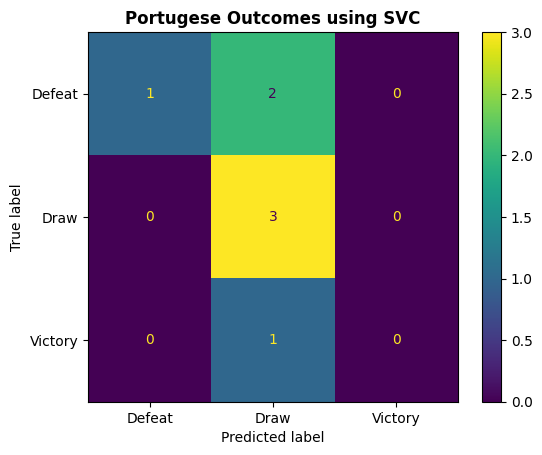

In [11]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Defeat', 'Draw', 'Victory'])

disp.plot()
plt.title('Portugese Outcomes using SVC', fontsize=12, fontweight='bold')
plt.show()

### Using a Random Forest Classifier

In [12]:
forest = RandomForestClassifier(n_estimators=100, random_state=12)
forest.fit(x_tr, y_tr) 

forest_pred = forest.predict(x_te)

ac_forest = accuracy_score(y_te, forest_pred)
cm_forest = confusion_matrix(y_te, forest_pred)
cr_forest = classification_report(y_te, forest_pred)

### Using a KNN Classifier

In [13]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(x_tr, y_tr)

knn_pred = knn.predict(x_te)

ac_knn = accuracy_score(y_te, knn_pred)
cm_knn = confusion_matrix(y_te, knn_pred)
cr_knn = classification_report(y_te, knn_pred)

### Results and Comparison of the SVC model to the Random Forest and KNN Models:

In [14]:
print(f'The accuracy score of the SVC model was {ac:3f}.')
print(f'The accuracy score of the Random Forest classifier was {ac_forest:3f}.')
print(f'The accuracy score of the KNN classifier was {ac_knn:3f}.')

The accuracy score of the SVC model was 0.571429.
The accuracy score of the Random Forest classifier was 0.428571.
The accuracy score of the KNN classifier was 0.428571.


### Based solely off of acccuracy we can note that the SVC model accurately predicted 57.14% of the ouctomes for the test data while the Random Forest model and the KNN model both only accurately predicted 42.86% of the outcomes for the Portugese correctly. This shows that the SVC model predicted the outcome more accurately almost 15% of the time which is statistically significant.  

In [15]:
print('\033[1mClassification report for SVC:\033[0m\n', cr)
print('\n\n\033[1mClassification report for Random Forest Model:\033[0m\n', cr_forest)
print('\n\n\033[1mClassification report for Knn Model :\033[0m\n', cr_knn)

Classification report for SVC:
               precision    recall  f1-score   support

          -1       1.00      0.33      0.50         3
           0       0.50      1.00      0.67         3
           1       0.00      0.00      0.00         1

    accuracy                           0.57         7
   macro avg       0.50      0.44      0.39         7
weighted avg       0.64      0.57      0.50         7



Classification report for Random Forest Model:
               precision    recall  f1-score   support

          -1       1.00      0.67      0.80         3
           0       0.33      0.33      0.33         3
           1       0.00      0.00      0.00         1

    accuracy                           0.43         7
   macro avg       0.44      0.33      0.38         7
weighted avg       0.57      0.43      0.49         7



Classification report for Knn Model :
               precision    recall  f1-score   support

          -1       1.00      0.33      0.50         3
      

### Looking at the classificaiton reports for each of the odels we can see that all of the models accurately predicted when the Portugese were defeated at 100% precision. However when we began to review the draw or victory values we can see that the SVC model predicted 50% of the draw outcomes while randome forest accruately predicted on 33% and the knn model accurately predicted on 40% of this outcome. All of the models had a 0% precision rate for the victory outcome. I reviewed my data exploration and found that there were at least 50% less data points for the victory outcome which may have caused the models to perform so poorely for the victory outcome. This was also a relatively small data set with on 28 rows of data. 

### The recall score shows the proportion of positively identified cases for each outcome. The SVC model showed that the model correctly predicted draws 100% of the time and classified the loses correctly as losses only 33% of the time. The Random Forest model showed that this model accurately predicted the loss outcome only 67% of the time and correctly identified the draw outcome only 33% of the time. Finally the KNN model correctly predicted and identified the loss outcome only 33% of the time and correctly predicted and identified the draw outcome 67% of the time. All of these models showed a 0% correctly identified victory for the portugese in this data model which again is most liely due to the small data set and only 5 rows that accounted for wins.  

### Overall based on the metrics and the classification report the SVC model was more accurate and identified the correct outcomes more consistently that the Random Forest or KNN models. This shows that the SVC model was better at the classification techniques for this data set. 